# Riffs Notebook
## DS 5001 — Constitution Corpus Analysis
**Author:** Aiden Rocha (atx2xs)

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram

plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')

data_prefix = 'const'
data_dir    = 'parsed_data'
table_dir   = 'derived_tables'
mod_dir = 'models'

REGIME_LABELS = {
    0: 'Closed Autocracy',
    1: 'Electoral Autocracy',
    2: 'Electoral Democracy',
    3: 'Liberal Democracy',
}
REGIME_COLORS = {
    'Closed Autocracy':    '#c0392b',
    'Electoral Autocracy': '#e67e22',
    'Electoral Democracy': '#2980b9',
    'Liberal Democracy':   '#27ae60',
}
REGIME_ORDER = ['Closed Autocracy', 'Electoral Autocracy',
                'Electoral Democracy', 'Liberal Democracy']

# NRC emotion columns present in your SENT table
EMOTION_COLS = ['anger', 'anticipation', 'disgust', 'fear',
                'joy', 'sadness', 'surprise', 'trust']

print('Setup complete.')

Setup complete.


## Load Data

In [2]:
LIB = pd.read_csv(f'{data_dir}/{data_prefix}_LIB.csv', index_col=0)
LIB['regime_label'] = LIB['regime_type'].map(REGIME_LABELS)

DCM   = pd.read_parquet(f'{table_dir}/const_DCM.parquet')            # (192, 5)  PC1..PC5
THETA = pd.read_csv(f'{mod_dir}/const-THETA.csv', index_col='country_id')  # (192, 40) T00..T39
SENT  = pd.read_csv(f'{mod_dir}/const_DOC_SENT.csv',  index_col='country_id')  # (192, 9)

print('LIB  :', LIB.shape)
print('DCM  :', DCM.shape)
print('THETA:', THETA.shape)
print('SENT :', SENT.shape)

LIB  : (192, 30)
DCM  : (192, 5)
THETA: (192, 40)
SENT : (192, 9)


---
## Riff 1 — NRC Emotion Profile by Regime Type
### Does Constitutional Emotional Language Differ Across Political Systems?

Uses all 8 NRC emotion dimensions from `DOC_SENT` to build an emotion profile for each regime type. Rather than a single sentiment score, this shows *which emotions* are most characteristic of each type of political system's constitutional language.

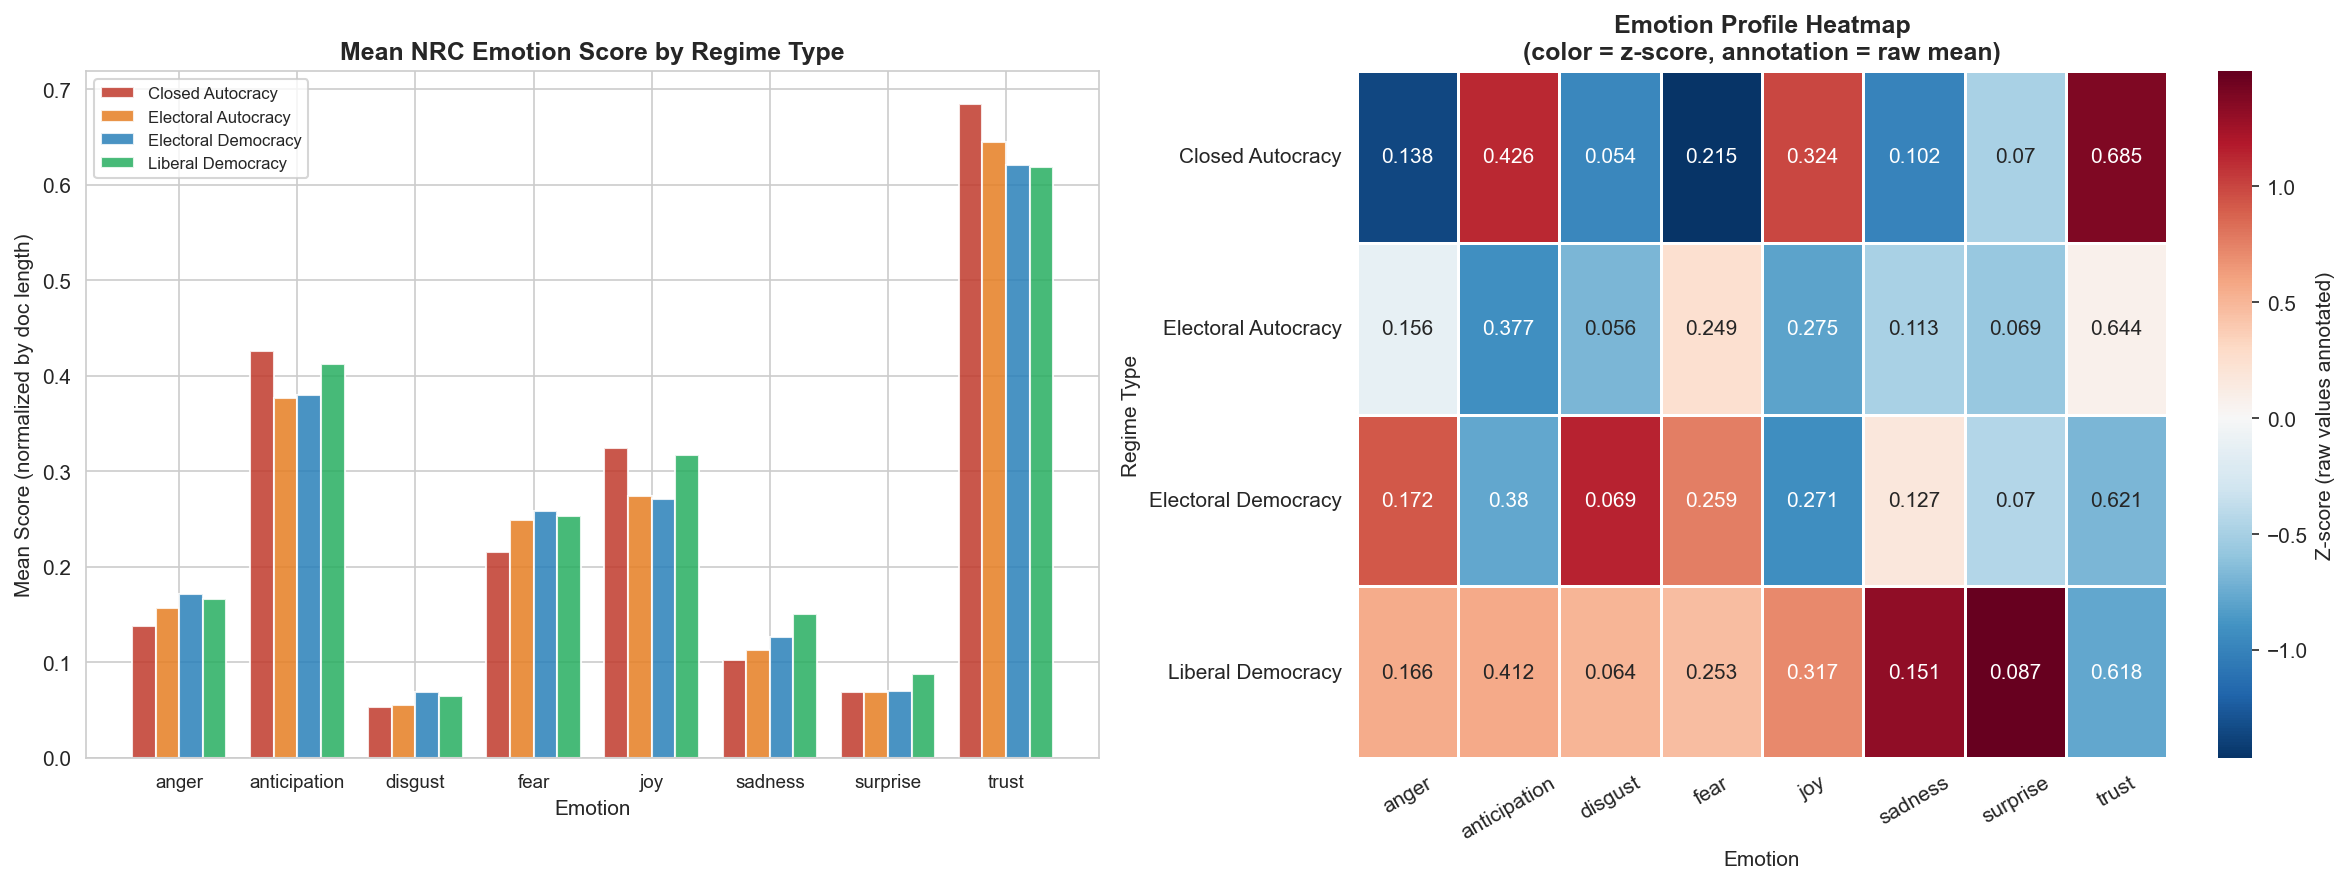

Saved → figures/riff1_emotion_regime.png


In [3]:
riff1 = (
    LIB[['country_name', 'regime_label', 'liberal_democracy', 'fh_total_score']]
    .join(SENT[EMOTION_COLS + ['sentiment']], how='inner')
    .dropna(subset=['regime_label'])
)

# ── Panel 1: mean emotion score per regime type (grouped bar chart) ────────────
emotion_means = riff1.groupby('regime_label')[EMOTION_COLS].mean().loc[REGIME_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
x = np.arange(len(EMOTION_COLS))
width = 0.2
for i, (regime, row) in enumerate(emotion_means.iterrows()):
    ax.bar(x + i * width, row.values, width,
           label=regime, color=REGIME_COLORS[regime], alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(EMOTION_COLS, fontsize=9)
ax.set_title('Mean NRC Emotion Score by Regime Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=10)
ax.set_ylabel('Mean Score (normalized by doc length)', fontsize=10)
ax.legend(fontsize=8)

# ── Panel 2: heatmap — regimes × emotions ─────────────────────────────────────
ax2 = axes[1]
# Z-score each emotion column so differences are visible on a common scale
emotion_z = (emotion_means - emotion_means.mean()) / emotion_means.std()
sns.heatmap(
    emotion_z,
    cmap='RdBu_r', center=0,
    annot=emotion_means.round(3), fmt='g',
    linewidths=0.5, linecolor='white',
    ax=ax2,
    cbar_kws={'label': 'Z-score (raw values annotated)'}
)
ax2.set_title('Emotion Profile Heatmap\n(color = z-score, annotation = raw mean)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Emotion', fontsize=10)
ax2.set_ylabel('Regime Type', fontsize=10)
ax2.tick_params(axis='x', rotation=30)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('figures/riff1_emotion_regime.png', bbox_inches='tight')
plt.show()
print('Saved → figures/riff1_emotion_regime.png')

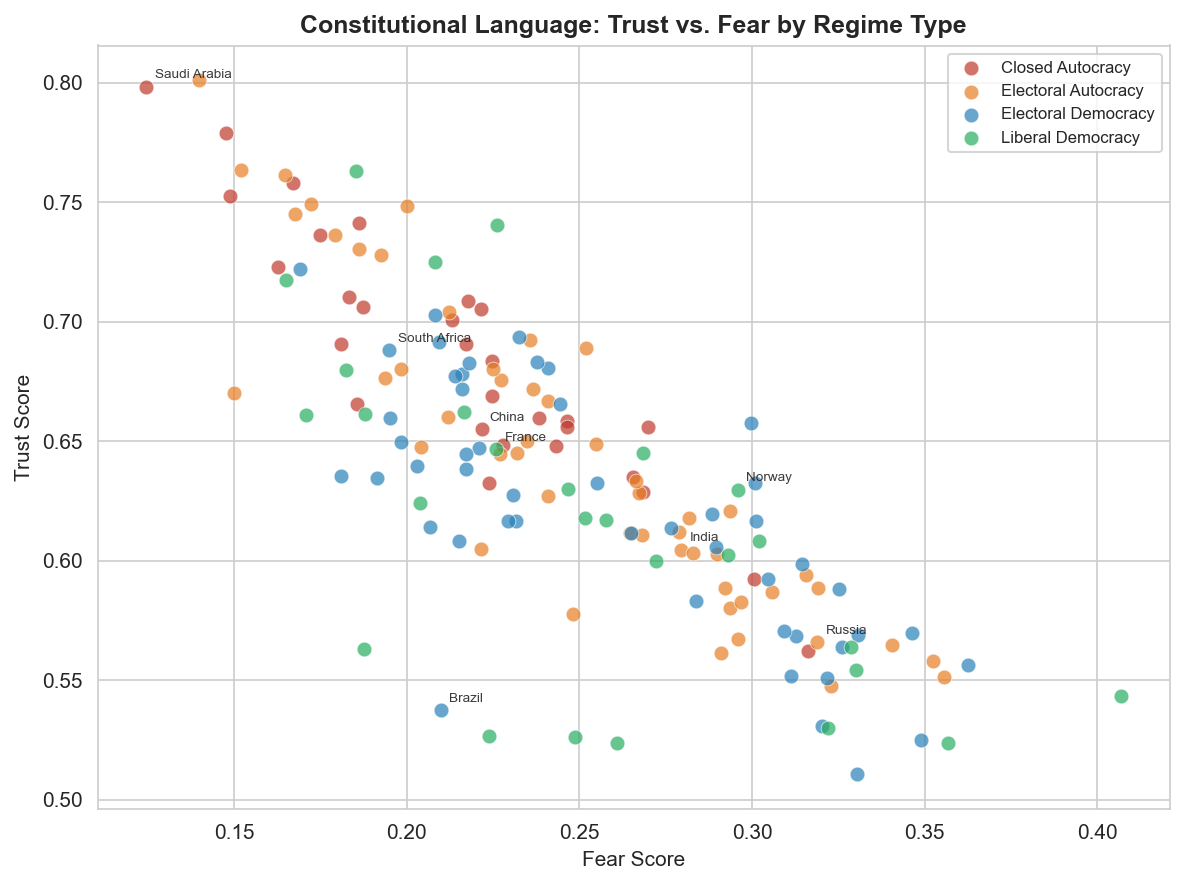

Saved → figures/riff1_trust_vs_fear.png


In [4]:
# ── Bonus: trust vs fear scatter, colored by regime ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for regime, grp in riff1.groupby('regime_label'):
    ax.scatter(grp['fear'], grp['trust'],
               color=REGIME_COLORS[regime], label=regime,
               alpha=0.7, s=50, edgecolors='white', linewidths=0.4)

# Annotate a few notable countries
notable = ['United States', 'Norway', 'China', 'Russia', 'Brazil', 'India',
           'Germany', 'Saudi Arabia', 'South Africa', 'France']
for _, row in riff1[riff1['country_name'].isin(notable)].iterrows():
    ax.annotate(row['country_name'], (row['fear'], row['trust']),
                fontsize=6.5, xytext=(4, 4), textcoords='offset points', alpha=0.9)

ax.set_title('Constitutional Language: Trust vs. Fear by Regime Type',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fear Score', fontsize=10)
ax.set_ylabel('Trust Score', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('figures/riff1_trust_vs_fear.png', bbox_inches='tight')
plt.show()
print('Saved → figures/riff1_trust_vs_fear.png')

### Riff 1 Interpretation

*(Fill in after running — suggested talking points below.)*

This riff uses the NRC Emotion Lexicon to build a full emotional profile of each constitution, then compares those profiles across V-Dem regime types. The grouped bar chart shows raw mean scores for each of the 8 emotions; the heatmap z-scores each emotion to reveal *relative* differences across regime types on a common scale. The bonus scatter contrasts **trust** vs. **fear** language directly.

- **Trust** is the emotion most associated with democratic legitimacy — language invoking public confidence in institutions. If liberal democracies score higher on trust, it would suggest their constitutions are written to build institutional confidence, while autocratic constitutions may rely more on fear or obligation.
- **Fear** language in constitutions may reflect an emphasis on threats, security, and punishment — elements more common in constitutions that concentrate power.
- **Anticipation** and **joy** may capture forward-looking, aspirational language — common in post-independence or post-transition constitutions that were written with optimism.
- Constitutions with high **fear** and low **trust** in the trust/fear scatter are worth examining individually: they may be constitutions written under conditions of instability or authoritarian consolidation.

---
## Riff 2 — PCA Space × Freedom House
### Do Constitutions Cluster by Civil Liberties in Textual Space?

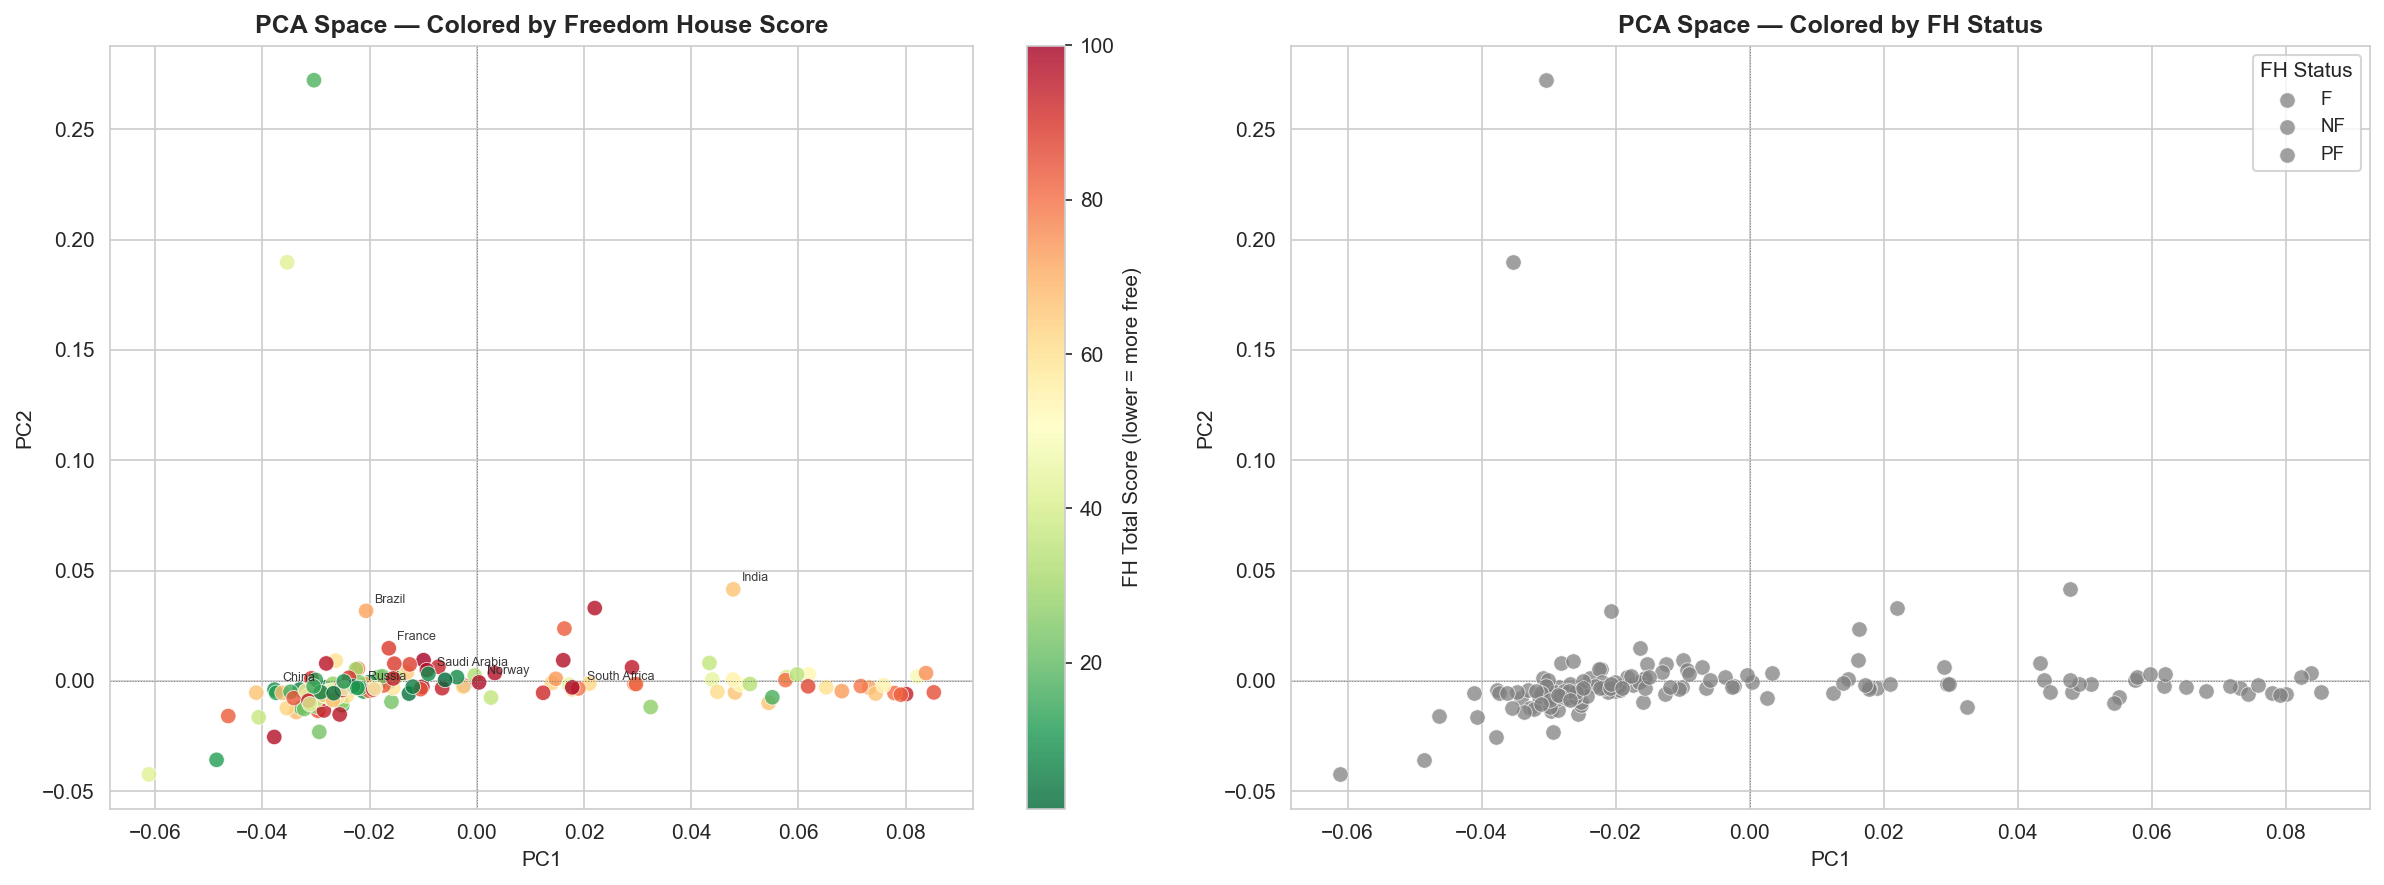

Saved → figures/riff2_pca_freedom_house.png


In [5]:
riff2 = (
    DCM[['PC1', 'PC2']]
    .join(LIB[['country_name', 'regime_label', 'regime_type',
               'fh_total_score', 'fh_status', 'liberal_democracy']], how='inner')
    .dropna(subset=['PC1', 'PC2'])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: continuous FH total score ───────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(
    riff2['PC1'], riff2['PC2'],
    c=riff2['fh_total_score'], cmap='RdYlGn_r',
    alpha=0.8, s=55, edgecolors='white', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='FH Total Score (lower = more free)')

notable = ['United States', 'Norway', 'China', 'Russia', 'Brazil',
           'India', 'Germany', 'France', 'Saudi Arabia', 'South Africa']
for _, row in riff2[riff2['country_name'].isin(notable)].iterrows():
    ax.annotate(row['country_name'], (row['PC1'], row['PC2']),
                fontsize=6, alpha=0.9, xytext=(4, 4), textcoords='offset points')
ax.axhline(0, color='grey', linewidth=0.5, linestyle=':')
ax.axvline(0, color='grey', linewidth=0.5, linestyle=':')
ax.set_title('PCA Space — Colored by Freedom House Score', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)

# ── Right: categorical FH status ──────────────────────────────────────────────
ax2 = axes[1]
fh_colors = {'Free': '#27ae60', 'Partly Free': '#f39c12', 'Not Free': '#c0392b'}
for status, grp in riff2.groupby('fh_status'):
    ax2.scatter(
        grp['PC1'], grp['PC2'],
        color=fh_colors.get(str(status), 'grey'),
        label=str(status), alpha=0.75, s=55,
        edgecolors='white', linewidths=0.4
    )
ax2.legend(title='FH Status', fontsize=9)
ax2.axhline(0, color='grey', linewidth=0.5, linestyle=':')
ax2.axvline(0, color='grey', linewidth=0.5, linestyle=':')
ax2.set_title('PCA Space — Colored by FH Status', fontsize=12, fontweight='bold')
ax2.set_xlabel('PC1', fontsize=10)
ax2.set_ylabel('PC2', fontsize=10)

plt.tight_layout()
plt.savefig('figures/riff2_pca_freedom_house.png', bbox_inches='tight')
plt.show()
print('Saved → figures/riff2_pca_freedom_house.png')

### Riff 2 Interpretation

*(Fill in after running — suggested talking points below.)*

This visualization maps all 192 constitutions into PC1/PC2 space and overlays Freedom House ratings. From your PCA notebook, PC1 was associated with terms like *speaker*, *clause*, *advice*, and *officer* — suggesting a parliamentary governance dimension. PC2 showed negative loadings on *chamber*, *deputies*, and *senate* — pointing toward differences in legislative structure (bicameral vs. unicameral).

- If Free and Not Free constitutions separate along PC1 or PC2, it suggests that structural constitutional choices are correlated with civil liberties outcomes — that how a constitution organizes government matters for how free it actually is.
- If the categories are well-mixed, it reinforces the idea that constitutional form does not predict political freedom. Authoritarian regimes frequently adopt democratic-sounding structural templates.
- The annotated countries provide a sanity check: where do established democracies (Norway, Germany) land relative to well-known autocracies (China, Russia, Saudi Arabia)? Surprising placements — an autocracy in the 'democratic' corner of the PCA space — would be a particularly interesting finding worth exploring.

---
## Riff 3 — LDA Topic Heatmap + Dendrogram by Regime Type
### Which Constitutional Topics Dominate Different Political Systems?

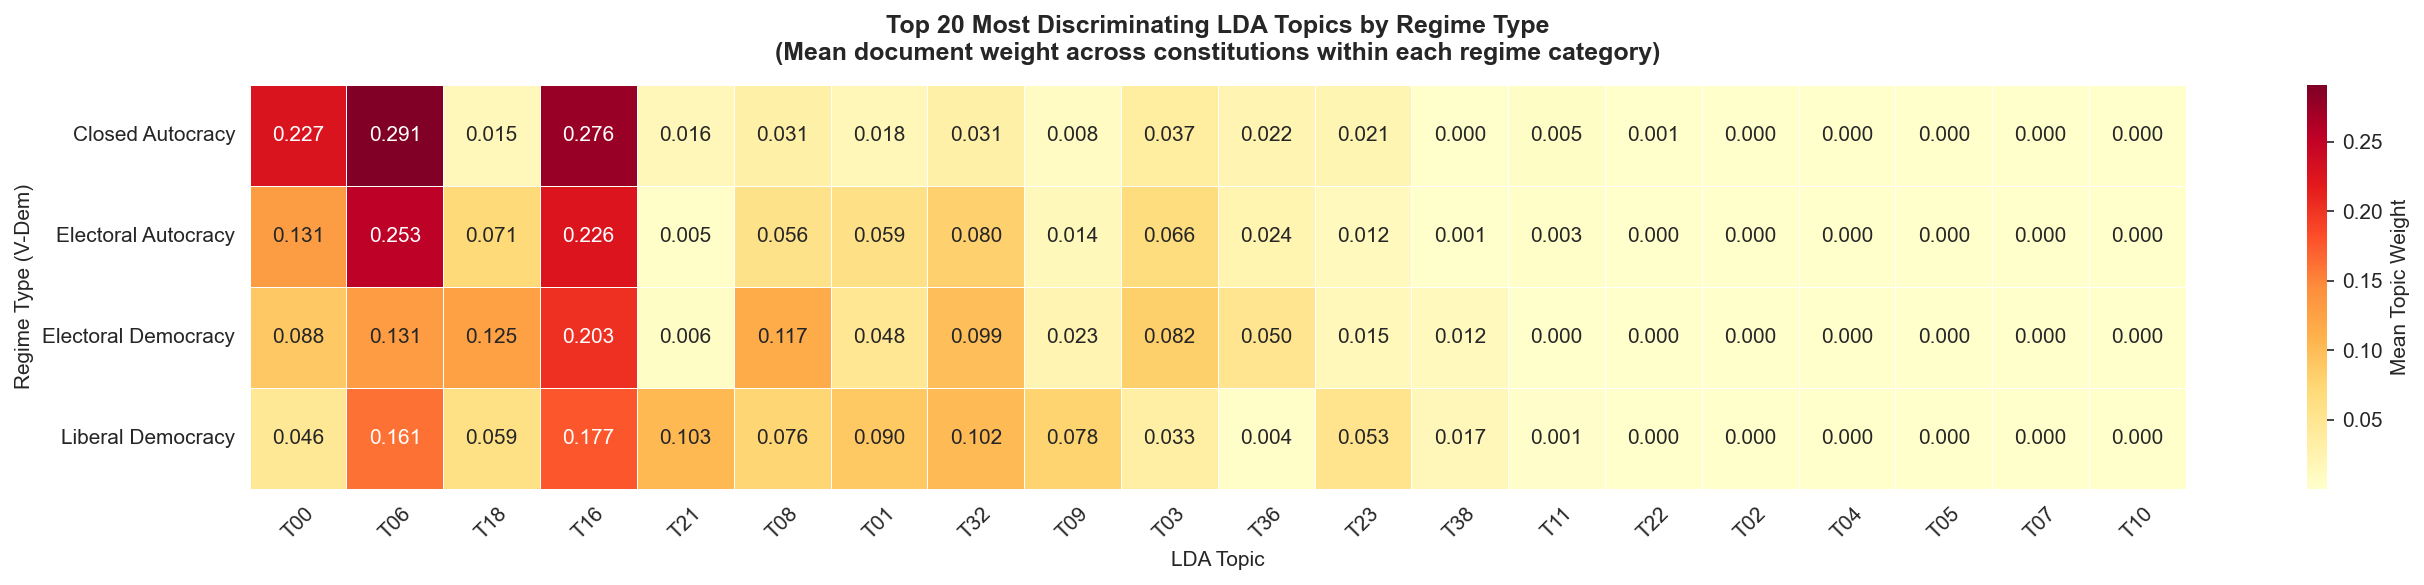

Saved → figures/riff3_lda_regime_heatmap.png


In [6]:
topic_cols = THETA.columns.tolist()  # T00..T39

riff3 = (
    LIB[['country_name', 'regime_type', 'regime_label']]
    .join(THETA, how='inner')
    .dropna(subset=['regime_type'])
)
riff3['regime_type'] = riff3['regime_type'].astype(int)

# Average topic weight per regime type, ordered
regime_topic_means = (
    riff3.groupby('regime_label')[topic_cols]
    .mean()
    .loc[[r for r in REGIME_ORDER if r in riff3['regime_label'].unique()]]
)

# Top 20 most discriminating topics
topic_range  = regime_topic_means.max() - regime_topic_means.min()
top_topics   = topic_range.nlargest(20).index.tolist()
heatmap_data = regime_topic_means[top_topics]

# ── Heatmap ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd', annot=True, fmt='.3f',
    linewidths=0.4, linecolor='white', ax=ax,
    cbar_kws={'label': 'Mean Topic Weight'}
)
ax.set_title(
    'Top 20 Most Discriminating LDA Topics by Regime Type\n'
    '(Mean document weight across constitutions within each regime category)',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('LDA Topic', fontsize=10)
ax.set_ylabel('Regime Type (V-Dem)', fontsize=10)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('figures/riff3_lda_regime_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved → figures/riff3_lda_regime_heatmap.png')

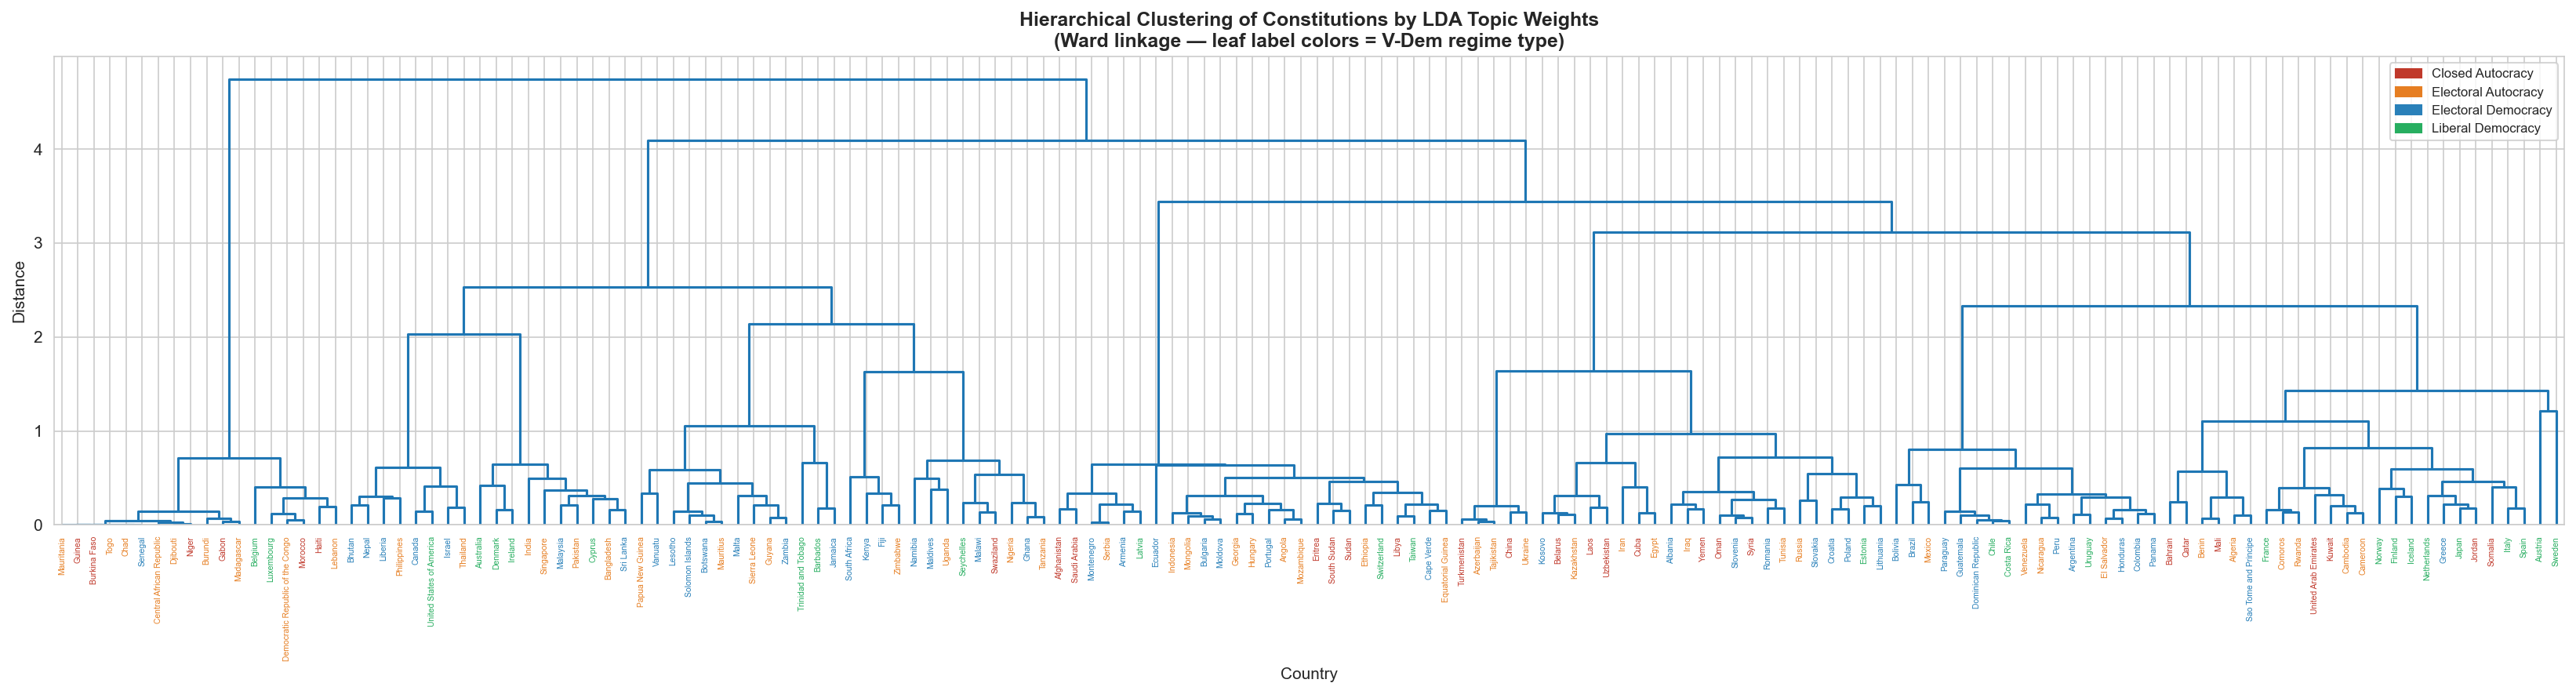

Saved → figures/riff3_lda_dendrogram.png


In [7]:
# ── Hierarchical dendrogram ────────────────────────────────────────────────────
theta_matrix       = riff3[topic_cols].values
country_labels_arr = riff3['country_name'].values
leaf_colors        = [REGIME_COLORS.get(r, 'grey') for r in riff3['regime_label'].values]

Z = linkage(theta_matrix, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(22, 6))
dendrogram(
    Z, labels=country_labels_arr,
    leaf_rotation=90, leaf_font_size=5,
    ax=ax, color_threshold=0
)
name_to_color = dict(zip(riff3['country_name'], leaf_colors))
for lbl in ax.get_xticklabels():
    lbl.set_color(name_to_color.get(lbl.get_text(), 'black'))

handles = [mpatches.Patch(color=v, label=k) for k, v in REGIME_COLORS.items()]
ax.legend(handles=handles, loc='upper right', fontsize=8)
ax.set_title(
    'Hierarchical Clustering of Constitutions by LDA Topic Weights\n'
    '(Ward linkage — leaf label colors = V-Dem regime type)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Country', fontsize=10)
ax.set_ylabel('Distance', fontsize=10)
plt.tight_layout()
plt.savefig('figures/riff3_lda_dendrogram.png', bbox_inches='tight')
plt.show()
print('Saved → figures/riff3_lda_dendrogram.png')

### Riff 3 Interpretation

*(Fill in after running — suggested talking points below.)*

**Heatmap:** Selects the 20 LDA topics with the greatest range across regime types — the topics most useful for distinguishing one political system from another. Darker cells mean constitutions of that regime type allocate more weight to that topic on average.
- Topics concentrated in autocracies may reflect centralized authority, security apparatus, or state-control language.
- Topics concentrated in liberal democracies likely capture rights, judicial independence, and accountability mechanisms.
- Topics uniform across all regime types represent the shared grammar of constitutionalism — elections, representation, law — language all states use regardless of how they actually govern.

**Dendrogram:** Clusters all 192 constitutions by their full 40-topic weight vectors using Ward linkage. Leaf labels are colored by V-Dem regime type. If regime types cluster together, the LDA topics are capturing politically meaningful variance in constitutional language. Constitutions that cluster with a different regime type are especially interesting — they may reflect shared legal traditions (post-Soviet templates, British colonial inheritance) or deliberate mimicry of democratic language by authoritarian states.

---
## Summary

| Riff | Tables Used | Question |
|------|-------------|----------|
| 1 | DOC_SENT (NRC) + LIB | Which emotions characterize constitutional language across regime types? |
| 2 | DCM (PC1/PC2) + LIB | Do constitutions cluster in PCA space by Freedom House status? |
| 3 | LDA THETA + LIB | Which constitutional topics discriminate across regime types? |